# SVM (SGDClassifier) — Wrapper Feature Selection (RFE)
**Dataset:** CIC-IDS 2017 (training) | CIC-IDS 2018 (cross-dataset evaluation)

**Pipeline:** Load data → Label grouping → Clean/preprocess → Label encoding → Train/test split → Feature scaling → RFE sweep → Model training → Evaluation → Cross-dataset validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/cicids2017_sample_1M_natural_standardized.csv"
raw_data = pd.read_csv(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,Dst Port,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Packets/s,Bwd Packets/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Header Length.1,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80.0,1,2,0,0,0,0,0,0.000000,0.000000,0,0,0.0,0.0,0.000000e+00,2.000000e+06,1.000000e+00,0.000000e+00,1,1,1,1.00,0.000000e+00,1,1,0,0.000,0.0,0,0,0,0,0,0,64,0,2.000000e+06,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.000000,0.000000,0.0,64,0,0,0,0,0,0,2,0,0,0,274,-1,0,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,DoS Hulk
1,53.0,226,2,2,64,204,32,32,32.000000,0.000000,102,102,102.0,0.0,1.185841e+06,1.769912e+04,7.533333e+01,8.848917e+01,174,3,49,49.00,0.000000e+00,49,49,3,3.000,0.0,3,3,0,0,0,0,40,40,8.849558e+03,8849.557522,32,102,60.000000,38.340579,1470.000000,0,0,0,0,0,0,0,0,1,75.000000,32.000000,102.0,40,0,0,0,0,0,0,2,64,2,204,-1,-1,1,20,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2,53.0,167,2,2,76,108,38,38,38.000000,0.000000,54,54,54.0,0.0,1.101796e+06,2.395210e+04,5.566667e+01,8.949488e+01,159,3,5,5.00,0.000000e+00,5,5,3,3.000,0.0,3,3,0,0,0,0,40,40,1.197605e+04,11976.047900,38,54,44.400000,8.763561,76.800000,0,0,0,0,0,0,0,0,1,55.500000,38.000000,54.0,40,0,0,0,0,0,0,2,76,2,108,-1,-1,1,20,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
3,53.0,101701,1,1,52,179,52,52,52.000000,0.000000,179,179,179.0,0.0,2.271364e+03,1.966549e+01,1.017010e+05,0.000000e+00,101701,101701,0,0.00,0.000000e+00,0,0,0,0.000,0.0,0,0,0,0,0,0,32,20,9.832745e+00,9.832745,52,179,94.333333,73.323484,5376.333333,0,0,0,0,0,0,0,0,1,141.500000,52.000000,179.0,32,0,0,0,0,0,0,1,52,1,179,-1,-1,0,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,80.0,1926259,5,0,30,0,6,6,6.000000,0.000000,0,0,0.0,0.0,1.557423e+01,2.595705e+00,4.815648e+05,9.624709e+05,1925271,1,1926259,481564.75,9.624709e+05,1925271,1,0,0.000,0.0,0,0,0,0,0,0,100,0,2.595705e+00,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,7.200000,6.000000,0.0,100,0,0,0,0,0,0,5,30,0,0,256,-1,4,20,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,DDoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864026,NaN,99912925,26,26,6674,156,1164,6,256.692322,366.020508,6,6,6.0,0.0,6.835952e+01,5.204532e-01,1.959077e+06,8.638857e+06,55000000,32,99900000,3996503.50,1.210000e+07,55000000,512,99900000,3996499.500,12100000.0,55000000,550,1,0,0,0,520,520,2.602266e-01,0.260227,6,1164,130.000000,283.225800,80216.843750,0,1,0,0,1,0,0,0,1,132.500000,256.692322,6.0,520,0,0,0,0,0,0,26,6674,26,156,255,1452,25,20,6.312257e+05,9.444298e+04,740279,576642,32500000.0,1.950000e+07,55000000,20900000,Infiltration
864027,NaN,111406728,21,21,4584,126,705,6,218.285721,254.824875,6,6,6.0,0.0,4.227752e+01,3.769970e-01,2.717237e+06,1.200000e+07,54800000,34,111000000,5570320.50,1.690000e+07,54800000,426,111000000,5570320.500,16900000.0

## 2. Label Distribution
Display the count and percentage distribution of raw attack labels, and visualise with a bar chart.

Label
BENIGN                        640639
DoS Hulk                      130108
DDoS                           72103
DoS GoldenEye                   5711
FTP-Patator                     4456
SSH-Patator                     3400
DoS slowloris                   3275
DoS Slowhttptest                3058
Web Attack � Brute Force         868
Web Attack � XSS                 361
Infiltration                      36
Heartbleed                        10
Web Attack � Sql Injection         6
Name: count, dtype: int64

% distribution:
Label
BENIGN                        74.15
DoS Hulk                      15.06
DDoS                           8.34
DoS GoldenEye                  0.66
FTP-Patator                    0.52
SSH-Patator                    0.39
DoS slowloris                  0.38
DoS Slowhttptest               0.35
Web Attack � Brute Force       0.10
Web Attack � XSS               0.04
Infiltration                   0.00
Heartbleed                     0.00
Web Attack � Sql Injection     0

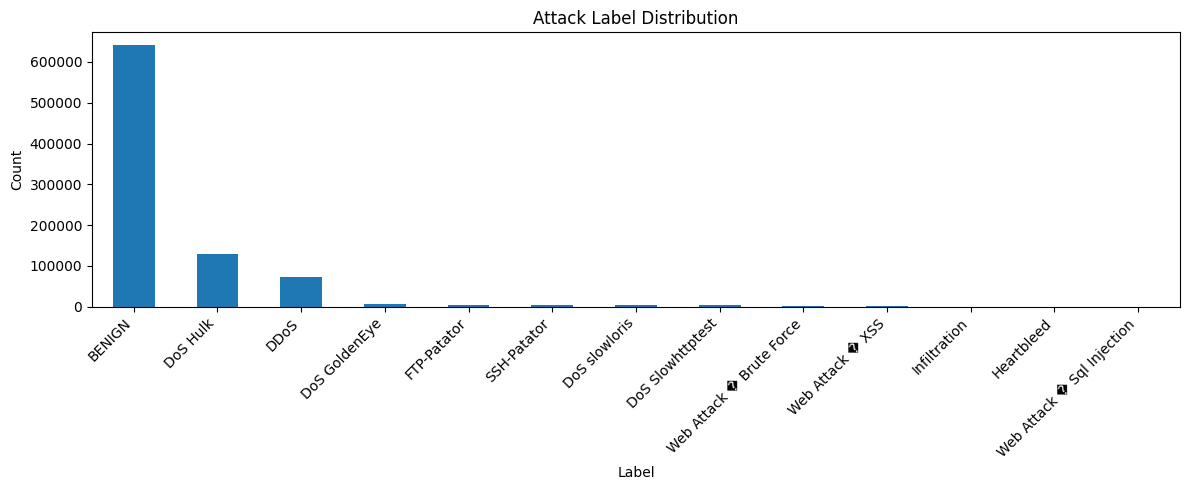

In [2]:
# ── Label distribution ──────────────────────────────────────────────────────
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\n% distribution:\n{(label_counts / len(df) * 100).round(2)}")

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Group Attack Labels
Map fine-grained attack labels to 5 high-level categories: BENIGN, DoS, DDoS, BruteForce, and Infiltration. Rows with unmapped labels are dropped.

In [3]:
# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'BENIGN': 'BENIGN',

    # DoS / DDoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    
    'DDoS': 'DDoS',

    # Brute Force
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    
    'Web Attack � XSS': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',

    'Heartbleed': 'Infiltration',
    'Infiltration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  BENIGN                  640,639  (74.43%)
  DoS                     138,877  (16.13%)
  DDoS                     72,103  (8.38%)
  BruteForce                9,085  (1.06%)
  Infiltration                 46  (0.01%)


## 4. Check Missing and Infinity Values
Audit the dataset for missing values and infinity values across all numeric columns before applying corrections.

In [4]:
# ── Check missing / infinity values ─────────────────────────────────────────
missing = df.isnull().sum()
print("MISSING VALUES\n", missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = {col: np.isinf(df[col]).sum()
              for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("\nINFINITY VALUES")
print(inf_counts if inf_counts else "None")


MISSING VALUES
 Dst Port        36
Flow Byts/s    717
dtype: int64

INFINITY VALUES
{'Flow Byts/s': np.int64(275), 'Flow Pkts/s': np.int64(992)}


## 5. Handle Infinity and Missing Values
Replace infinity values with NaN then fill remaining NaN entries using the column median to ensure a clean numeric dataset.

In [5]:
# ── Handle inf → NaN → fill with median ─────────────────────────────────────
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"NaN remaining : {df_processed.isnull().sum().sum()}")
print(f"Shape         : {df_processed.shape}")


NaN remaining : 0
Shape         : (860750, 79)


/tmp/ipykernel_55677/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_55677/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

## 6. Drop Identifier and Metadata Columns
Remove non-feature columns such as flow IDs, IP addresses, timestamps, and port numbers that would not generalise across datasets.

In [6]:
# ── Drop identifier / metadata columns ──────────────────────────────────────
keywords = ['dst port']
cols_to_drop = [c for c in df_processed.columns
                if any(k in c.lower() for k in keywords)]

df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped : {cols_to_drop}")
print(f"Shape   : {df_processed.shape}")


Dropped : ['Dst Port']
Shape   : (860750, 78)


## 7. Label Encoding
Encode the grouped attack labels as integers using `LabelEncoder` and persist the encoder to disk for later cross-dataset evaluation.

In [7]:
# ── Label encoding ───────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

for idx, label in enumerate(le.classes_):
    print(f"{idx}: {label}  ({(df_processed['Label_Encoded']==idx).sum()} samples)")


0: BENIGN  (640639 samples)
1: BruteForce  (9085 samples)
2: DDoS  (72103 samples)
3: DoS  (138877 samples)
4: Infiltration  (46 samples)


## 8. Train / Test Split
Perform a stratified 80/20 split to create training and test sets while preserving the class distribution.

In [8]:
# ── Train / test split (stratified 80/20) ────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")


Train : (688600, 77)  |  Test : (172150, 77)


## 9. Feature Scaling (StandardScaler)
Fit `StandardScaler` on training data and transform both training and test sets. The fitted scaler is saved to disk for consistent transformation during cross-dataset evaluation.

> **Note:** The following two cells both perform scaling; the second supersedes the first.

In [9]:
# ── Feature scaling (StandardScaler) ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

with open('scaler.pkl1', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train scaled : {X_train_scaled.shape}  |  Test scaled : {X_test_scaled.shape}")


Train scaled : (688600, 77)  |  Test scaled : (172150, 77)


In [10]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

with open('scaler.pkl1', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")


Train: (688600, 77)  |  Test: (172150, 77)


## 10. RFE Feature Selection — Sweep and Baseline

# Overview of RFE (Recursive Feature Elimination) Technique
**RFE** (Recursive Feature Elimination) is a feature selection method that optimizes models by retaining the most important variables and eliminating weak ones.

### 1. Baseline Model
- **Definition:** A model trained using **all** the original features (without using Feature Selection).
- **Purpose:** Used as a benchmark when evaluating on the `X_test` set. Subsequent optimization results will be compared with the Baseline to see the improvement.

### 2. RFE Sweep
Instead of fixing a number, we sweep through a list of values ​​$k$ (the number of features to retain) to find the best result.

- **Example:** `k_values ​​= [10, 20, 30, 40, 50, 60, 70]`
- **Execution:** The system will run RFE for each case: trying to keep 10 features, 20 features,... up to 70 features.

### 3. Recursive Elimination Process
In each iteration searching for $k$ features, the algorithm performs the following steps:
1. **Training:** Build a machine learning model (e.g., Decision Tree).
2. **Evaluation:** Calculate the importance of each feature.
3. **Elimination:** Discard the weakest features.
4. **Iteration:** The process is repeated until only $k$ features remain.
> **Speed-Up Tip (Step Value):** > If the dataset has 80 features, instead of slowly removing each variable one by one, we can set the `step` parameter to remove multiple variables at once in each round. For example, forcing the number to drop quickly from 80 to 20 significantly speeds up the RFE algorithm.

### 4. Post-Selection Testing
After the RFE has finished selecting the $k$ features, we re-test the model:
- At this point, the model **only uses the selected features** to predict and measure accuracy.

- The results for each $k$ value are saved and displayed for comparison.
### 5. Guide to Reading and Analyzing Results

Assuming the output of the run is as follows:
```text
Baseline: 99.76%
Best k=20: 99.68%
It means: only need 20 features accuracy only decreases by 0.08%

In [ ]:

# RFE — sweep k
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

sgd_baseline = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                               eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
sgd_baseline.fit(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, sgd_baseline.predict(X_test_scaled))

base_estimator = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                                eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
k_values = [k for k in [10, 20, 30, 40, 50, 60, 70] if k < X_train_scaled.shape[1]]
rfe_results = {}

for k in k_values:
    rfe = RFE(estimator=base_estimator, n_features_to_select=k, step=140)
    rfe.fit(X_train_scaled, y_train)
    selected_feats = X_train_scaled.columns[rfe.support_].tolist()
    # Evaluate using the same final-model hyperparams to avoid discrepancy
    sgd_tmp = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                             eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
    sgd_tmp.fit(X_train_scaled[selected_feats], y_train)
    rfe_results[k] = {'accuracy': accuracy_score(y_test, sgd_tmp.predict(X_test_scaled[selected_feats])), 'support': rfe.support_}

best_k = max(rfe_results, key=lambda k: rfe_results[k]['accuracy'])
print(f"Baseline: {test_acc*100:.2f}%  |  Best k={best_k}: {rfe_results[best_k]['accuracy']*100:.2f}%")


## 11. Feature Ranking and RFE Model Training
Refit RFE with the best-k value, plot a horizontal bar chart of feature importances (mean |coef|), train the final SGDClassifier on selected features, and persist the model and feature list to disk.

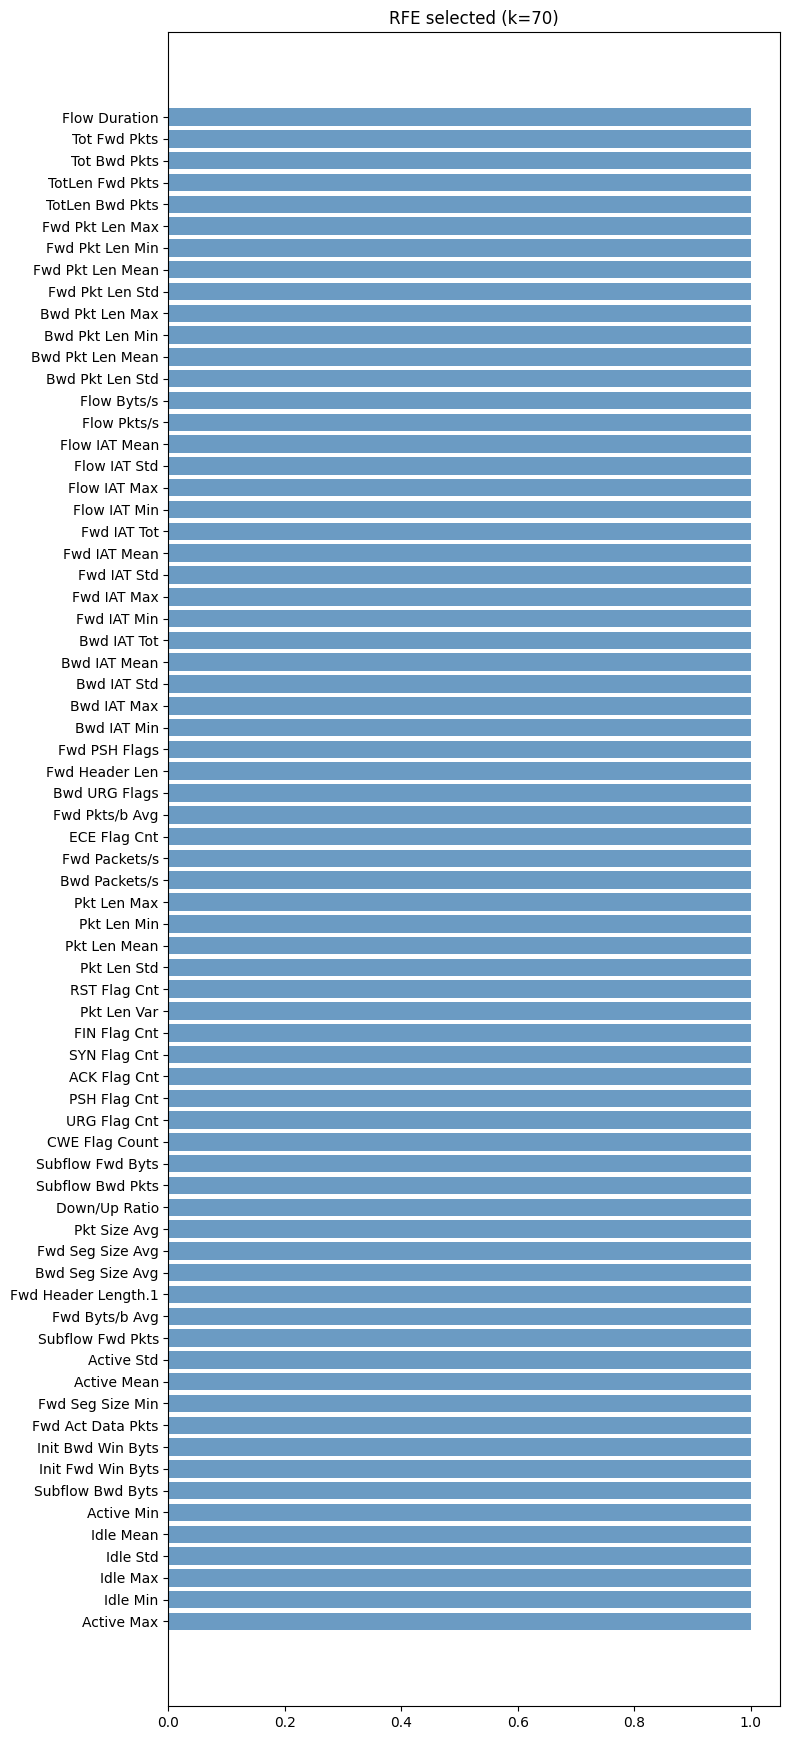

In [ ]:

# Feature ranking (RFE best_k) — importance via mean |coef_| across classes
best_rfe = RFE(estimator=SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
               eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42),
               n_features_to_select=best_k, step=140)
best_rfe.fit(X_train_scaled, y_train)

rfe_features = X_train_scaled.columns[best_rfe.support_].tolist()
importance = np.abs(best_rfe.estimator_.coef_).mean(axis=0)

ranking_df = pd.DataFrame({'Feature': rfe_features, 'Importance': importance})
selected_df = ranking_df.sort_values('Importance', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(4, best_k * 0.25)))
ax.barh(selected_df['Feature'], selected_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title(f'RFE selected (k={best_k})'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Reuse best_rfe for cross-dataset validation (no re-training) ──────────────
import pickle

sgd_rfe = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                         eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
sgd_rfe.fit(X_train_scaled[rfe_features], y_train)

rfe_sorted = pd.Series(np.abs(best_rfe.estimator_.coef_).mean(axis=0),
                        index=rfe_features).sort_values(ascending=False)

print(f"=== RFE k={best_k} Features (by |coef| importance) ===")
for i, (feat, imp) in enumerate(rfe_sorted.items(), 1):
    print(f"  {i:2d}. {feat:<45} importance={imp:.4f}")

with open('sgd_rfe20_model.pkl', 'wb') as f: pickle.dump(sgd_rfe, f)
with open('rfe20_selected_features.pkl', 'wb') as f: pickle.dump(rfe_features, f)


## 12. Classification Report — RFE Model
Per-class precision, recall, F1-score, and support for the SGDClassifier trained on the RFE-selected features, evaluated on the held-out test set.

In [ ]:

# ── Classification report ─────────────────────────────────────────────────────
y_test_pred = sgd_rfe.predict(X_test_scaled[rfe_features])
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


## 13. Confusion Matrix — RFE Model
Side-by-side heatmaps showing the count and percentage confusion matrix for the SGDClassifier RFE model on the CIC-IDS 2017 test set.

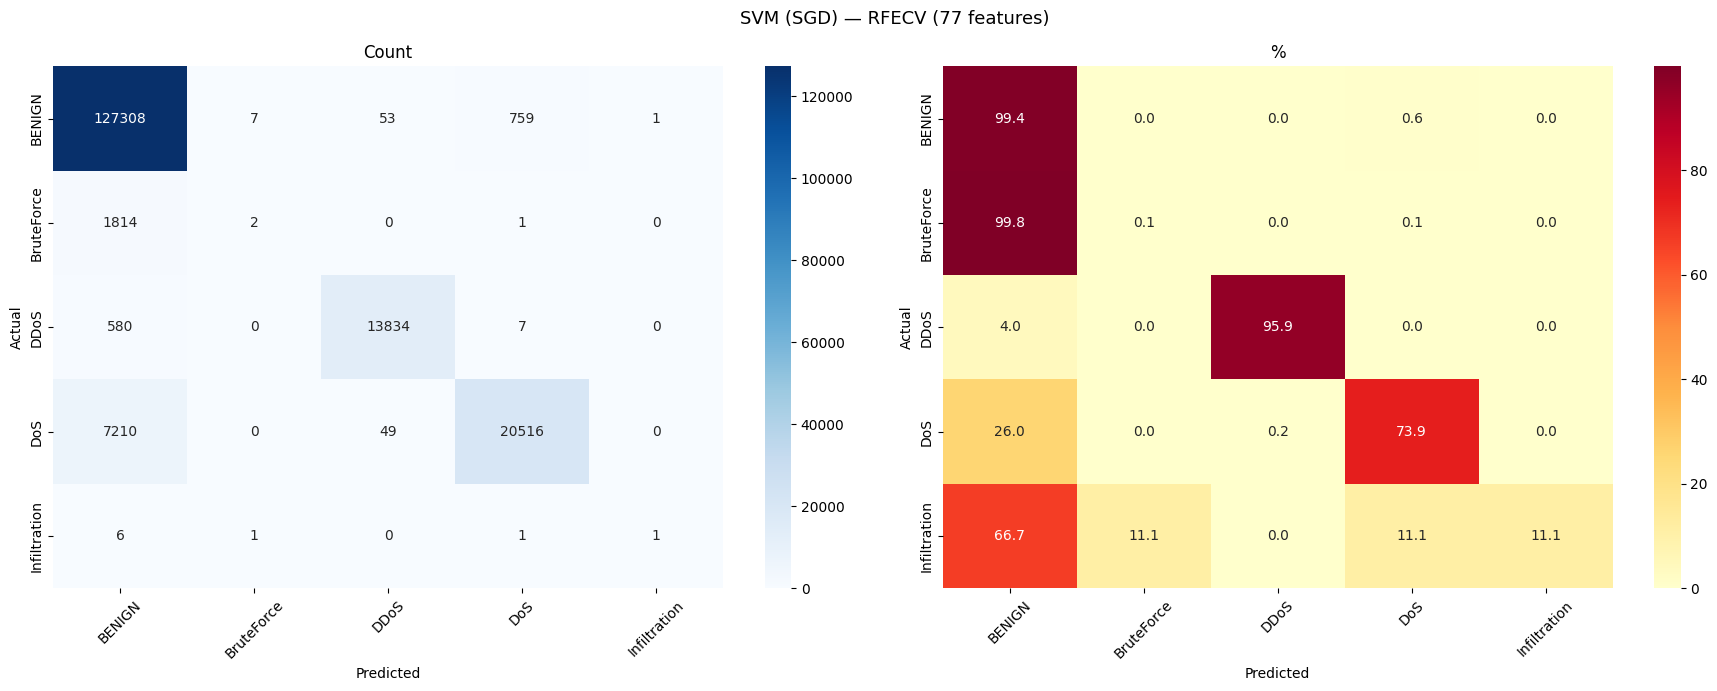

In [ ]:

# Confusion matrix — RFE best_k model
cm = confusion_matrix(y_test, sgd_rfe.predict(X_test_scaled[rfe_features]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Count'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual'); ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('%'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual'); ax2.tick_params(axis='x', rotation=45)

plt.suptitle(f'SVM (SGD) — RFE k={best_k} features', fontsize=13)
plt.tight_layout(); plt.show()


## 14. Load CIC-IDS 2018 Dataset
Load the CIC-IDS 2018 parquet dataset for cross-dataset evaluation to measure how well the model trained on 2017 data transfers to a different year.

In [ ]:
# ── Load CIC-IDS 2018 dataset ────────────────────────────────────────────────
CIC18_PATH = "../../../../dataset/cic2018_balanced_dataset_standardized.parquet"
df18_raw = pd.read_parquet(CIC18_PATH)
print(f"Shape : {df18_raw.shape}")
print(df18_raw['Label'].value_counts())

Shape : (263647, 81)
Label
Benign                      49999
DDOS attack-HOIC            25000
DDoS attacks-LOIC-HTTP      25000
DoS attacks-Hulk            25000
DoS attacks-SlowHTTPTest    25000
DoS attacks-GoldenEye       25000
SSH-Bruteforce              25000
FTP-BruteForce              25000
Infilteration               25000
DoS attacks-Slowloris       10990
DDOS attack-LOIC-UDP         1730
Brute Force -Web              611
Brute Force -XSS              230
SQL Injection                  87
Name: count, dtype: Int64

File 2018 là BALANCED dataset - class distribution không phản ánh thực tế.


## 15. Group CIC-2018 Attack Labels
Apply the same attack-group mapping to the 2018 dataset labels to align them with the 5 categories used during training.

In [ ]:
# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping_18 = {
    # # BENIGN
    'Benign': 'BENIGN',

    # DoS / DDoS
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-Slowhttptest': 'DoS',
    
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDoS attacks-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',

    # Brute Force
    'FTP-BruteForce': 'BruteForce',
    'SSH-Bruteforce': 'BruteForce',
    
    'Brute Force -Web': 'BruteForce',
    'Brute Force -XSS': 'BruteForce',

    'Infilteration': 'Infiltration',
}

df18 = df18_raw.copy()
df18['Label'] = df18['Label'].map(attack_group_mapping_18)
df18.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df18['Label'].nunique()}")
for g, cnt in df18['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df18)*100:.2f}%)")


Groups after mapping : 5
  DoS                      60,990  (25.75%)
  BruteForce               50,841  (21.47%)
  DDoS                     50,000  (21.11%)
  BENIGN                   49,999  (21.11%)
  Infiltration             25,000  (10.56%)


## 16. Preprocess CIC-2018 Data
Apply the same preprocessing pipeline as CIC-2017: replace infinities, fill NaN with median, and drop metadata columns.

In [ ]:
# ── Preprocess 2018 data (same pipeline as 2017) ─────────────────────────────
df18_proc = df18.copy()

# 1. inf -> NaN -> median fill
df18_proc.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df18_proc.select_dtypes(include=[np.number]).columns:
    if df18_proc[col].isnull().sum() > 0:
        df18_proc[col].fillna(df18_proc[col].median(), inplace=True)

# 2. Drop identifier / metadata columns
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop_18 = [c for c in df18_proc.columns
                   if any(k in c.lower() for k in keywords)]
df18_proc.drop(columns=cols_to_drop_18, inplace=True, errors='ignore')

print(f"NaN remaining : {df18_proc.isnull().sum().sum()}")
print(f"Shape         : {df18_proc.shape}")

NaN remaining : 0
Shape         : (236830, 79)


/tmp/ipykernel_40261/3236478823.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df18_proc[col].fillna(df18_proc[col].median(), inplace=True)
/tmp/ipykernel_40261/3236478823.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

## 17. Cross-Dataset Evaluation — RFE Features
Evaluate the RFE-trained SGDClassifier on CIC-IDS 2018 using only the features shared between the two datasets. Features are scaled with a freshly fitted `StandardScaler` for both train and test sets.

In [ ]:

# Cross-test — RFE best_k shared features
shared_features = [f for f in rfe_features if f in df18_proc.columns]
missing_in_17 = [f for f in rfe_features if f not in df18_proc.columns]

print(f"RFE k={best_k}: {len(rfe_features)} features  |  Shared with CIC-2018: {len(shared_features)}  |  Missing: {len(missing_in_17)}")
if missing_in_17:
    print(f"  Missing features: {missing_in_17}")

X18 = df18_proc[shared_features]
y18_labels = df18_proc['Label']

known_classes = set(le.classes_)
mask_known = y18_labels.isin(known_classes)
X18 = X18[mask_known]
y18_labels = y18_labels[mask_known]
y18 = le.transform(y18_labels)

scaler_sub = StandardScaler()
X_train_sub_s = scaler_sub.fit_transform(X_train[shared_features])
X_test_sub_s  = scaler_sub.transform(X_test[shared_features])
X18_sub_s     = scaler_sub.transform(X18)

SGD_Shared = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                            eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
SGD_Shared.fit(X_train_sub_s, y_train)
y18_pred = SGD_Shared.predict(X18_sub_s)
acc_src  = accuracy_score(y_test, SGD_Shared.predict(X_test_sub_s))

acc18 = accuracy_score(y18, y18_pred)
print(f"\nCIC-2017 (source): {acc_src*100:.2f}%")
print(f"CIC-2018 (target): {acc18*100:.2f}%  |  Drop: {(acc_src-acc18)*100:.2f}%")
print()
present_indices = sorted(set(y18))
print(classification_report(y18, y18_pred, labels=present_indices,
                             target_names=le.inverse_transform(present_indices),
                             digits=4, zero_division=0))


/home/huyho/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


CIC-2018 (source): 93.91%
CIC-2017 (target): 21.68%  |  Drop: 72.23%

              precision    recall  f1-score   support

      BENIGN     0.2152    0.9485    0.3508     49999
  BruteForce     0.0000    0.0000    0.0000     50841
        DDoS     0.0000    0.0000    0.0000     50000
         DoS     0.2406    0.0643    0.1015     60990
Infiltration     0.0000    0.0000    0.0000     25000

    accuracy                         0.2168    236830
   macro avg     0.0911    0.2026    0.0905    236830
weighted avg     0.1074    0.2168    0.1002    236830



## 18. Covariate Shift Visualisation
Plot KDE distributions for the top RFE features side-by-side for CIC-2017 (blue) and CIC-2018 (red) per attack class to visually diagnose feature distribution shift between the two datasets.

In [ ]:

# ── Covariate Shift Visualization ────────────────────────────────────────────
# Top-N most important features from RFE
TOP_N = 5
top_features = rfe_sorted.head(TOP_N).index.tolist()

# Build per-class DataFrames for 2017 (train+test) and 2018
df_src = X_train[top_features].copy()
df_src['_label'] = le.inverse_transform(y_train.values)

df_tgt_full = df18_proc[top_features + ['Label']].copy()
df_tgt_full = df_tgt_full[df_tgt_full['Label'].isin(le.classes_)]
df_tgt_full.rename(columns={'Label': '_label'}, inplace=True)

classes = sorted(le.classes_)
palette_src = '#2196F3'
palette_tgt = '#F44336'

fig, axes = plt.subplots(len(top_features), len(classes),
                         figsize=(4 * len(classes), 3.5 * len(top_features)),
                         squeeze=False)

from scipy.stats import gaussian_kde

for row, feat in enumerate(top_features):
    for col, cls in enumerate(classes):
        ax = axes[row][col]
        vals_src = df_src.loc[df_src['_label'] == cls, feat].dropna().values
        vals_tgt = df_tgt_full.loc[df_tgt_full['_label'] == cls, feat].dropna().values

        for vals, color, label in [
            (vals_src, palette_src, 'CIC-2017'),
            (vals_tgt, palette_tgt, 'CIC-2018'),
        ]:
            if len(vals) < 5:
                continue
            # clip extreme outliers for readability
            lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
            vals_clip = vals[(vals >= lo) & (vals <= hi)]
            if len(vals_clip) < 5:
                continue
            kde = gaussian_kde(vals_clip, bw_method='scott')
            xs = np.linspace(vals_clip.min(), vals_clip.max(), 300)
            ax.fill_between(xs, kde(xs), alpha=0.35, color=color)
            ax.plot(xs, kde(xs), color=color, linewidth=1.8, label=label)

        ax.set_title(f'{cls}', fontsize=9)
        if col == 0:
            ax.set_ylabel(feat, fontsize=8)
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)
        if row == 0 and col == len(classes) - 1:
            ax.legend(fontsize=8)

fig.suptitle(
    f'Covariate Shift — Top-{TOP_N} RFE Features\n'
    'Blue = CIC-2017 (source)  |  Red = CIC-2018 (target)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()
